# Perbandingan Random Forest dan XGBoost untuk Network Intrusion Detection

Notebook ini mengikuti 5 tahap metodologi Data Science dari materi kuliah:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Model Evaluation

## 1. Business Understanding

**Masalah bisnis:** lalu lintas jaringan dapat mengandung koneksi normal dan koneksi berbahaya. Deteksi manual sulit dilakukan karena volume koneksi tinggi dan pola serangan dapat bervariasi.

**Tujuan project:** membangun dan membandingkan model klasifikasi untuk mendeteksi apakah sebuah koneksi jaringan termasuk normal atau anomalous.

**Tugas analitik:** klasifikasi biner.

**Model yang dibandingkan:** Random Forest dan XGBoost.

**Metrik evaluasi:** accuracy, precision, recall/sensitivity, specificity, F1-score, confusion matrix, dan ROC-AUC.

## 2. Data Understanding

Dataset Kaggle yang digunakan memiliki file `Train_data.csv` dengan label `class` dan `Test_data.csv` tanpa label. Karena evaluasi membutuhkan label aktual, eksperimen model dilakukan dengan membagi `Train_data.csv` menjadi data latih dan data uji internal.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
DATA_PATH = Path("../data/raw/Train_data.csv")

# Jika file CSV tidak memiliki header, gunakan daftar kolom NSL-KDD berikut.
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "class"
]

df = pd.read_csv(DATA_PATH)

display(df.head())
print(df.shape)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


(25192, 42)


In [3]:
df.info()
display(df.describe(include="all").T)
display(df.isna().sum().sort_values(ascending=False).head(20))
print("Duplicate rows:", df.duplicated().sum())
display(df["class"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  object 
 2   service                      25192 non-null  object 
 3   flag                         25192 non-null  object 
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised              25192 non-null  int64  
 13  root_shell      

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
duration,25192.0,NaN,NaN,NaN,305.054104,2686.55564,0.0,0.0,0.0,0.0,42862.0
protocol_type,25192,3,tcp,20526,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service,25192,66,http,8003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flag,25192,11,SF,14973,NaN,NaN,NaN,NaN,NaN,NaN,NaN
src_bytes,25192.0,NaN,NaN,NaN,24330.628215,2410805.402028,0.0,0.0,44.0,279.0,381709090.0
dst_bytes,25192.0,NaN,NaN,NaN,3491.847174,88830.71833,0.0,0.0,0.0,530.25,5151385.0
land,25192.0,NaN,NaN,NaN,0.000079,0.00891,0.0,0.0,0.0,0.0,1.0
wrong_fragment,25192.0,NaN,NaN,NaN,0.023738,0.260221,0.0,0.0,0.0,0.0,3.0
urgent,25192.0,NaN,NaN,NaN,0.00004,0.0063,0.0,0.0,0.0,0.0,1.0
hot,25192.0,NaN,NaN,NaN,0.198039,2.154202,0.0,0.0,0.0,0.0,77.0


duration              0
protocol_type         0
service               0
flag                  0
src_bytes             0
dst_bytes             0
land                  0
wrong_fragment        0
urgent                0
hot                   0
num_failed_logins     0
logged_in             0
num_compromised       0
root_shell            0
su_attempted          0
num_root              0
num_file_creations    0
num_shells            0
num_access_files      0
num_outbound_cmds     0
dtype: int64

Duplicate rows: 0


class
normal     13449
anomaly    11743
Name: count, dtype: int64

## 3. Data Preparation

Target binary dibuat dengan aturan: `normal` = 0 dan selain `normal` = 1 atau anomalous.

In [4]:
df_model = df.copy()
df_model["target"] = (df_model["class"] != "normal").astype(int)

X = df_model.drop(columns=["class", "target"])
y = df_model["target"]

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Number of numeric features:", len(numeric_features))
display(y.value_counts().rename(index={0: "normal", 1: "anomalous"}))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

Categorical features: ['protocol_type', 'service', 'flag']
Number of numeric features: 38


target
normal       13449
anomalous    11743
Name: count, dtype: int64

## 4. Modeling

In [5]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced")),
    ]
)

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

xgb_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight,
        )),
    ]
)

rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## 5. Model Evaluation

In [6]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)

    result = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall_sensitivity": recall_score(y_test, y_pred),
        "specificity": specificity,
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

    print(name)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=["normal", "anomalous"]))
    return result

In [7]:
results = [
    evaluate_model("Random Forest", rf_pipeline, X_test, y_test),
    evaluate_model("XGBoost", xgb_pipeline, X_test, y_test),
]
results_df = pd.DataFrame(results)
display(results_df)

Random Forest
[[4031    4]
 [  19 3504]]
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00      4035
   anomalous       1.00      0.99      1.00      3523

    accuracy                           1.00      7558
   macro avg       1.00      1.00      1.00      7558
weighted avg       1.00      1.00      1.00      7558

XGBoost
[[4028    7]
 [  17 3506]]
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00      4035
   anomalous       1.00      1.00      1.00      3523

    accuracy                           1.00      7558
   macro avg       1.00      1.00      1.00      7558
weighted avg       1.00      1.00      1.00      7558



,model,accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc
0,Random Forest,0.996957,0.998860,0.994607,0.999009,0.996729,0.999939
1,XGBoost,0.996825,0.998007,0.995175,0.998265,0.996589,0.999949


## 6. Visualisasi Data Understanding

Visualisasi berikut digunakan untuk memperjelas distribusi kelas target dan karakteristik fitur kategorikal utama.

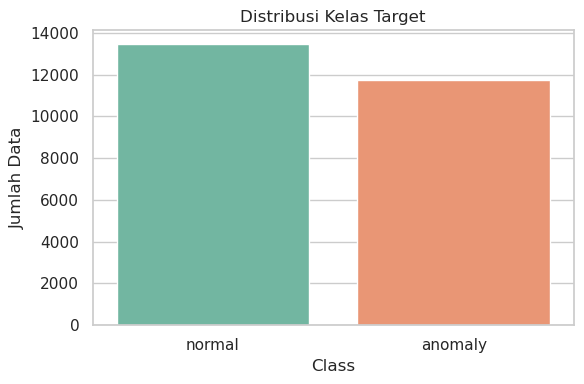

,jumlah,persentase
class,,
normal,13449,53.39
anomaly,11743,46.61


In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="class", hue="class", palette="Set2", legend=False)
plt.title("Distribusi Kelas Target")
plt.xlabel("Class")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.show()

class_distribution = df["class"].value_counts().to_frame("jumlah")
class_distribution["persentase"] = (class_distribution["jumlah"] / len(df) * 100).round(2)
display(class_distribution)

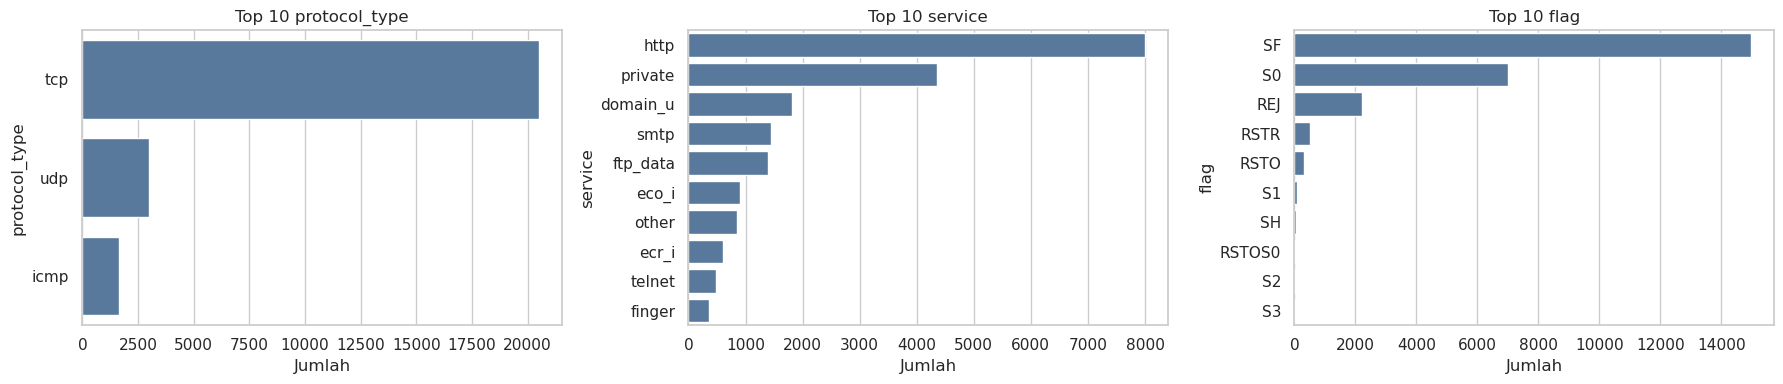

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, ["protocol_type", "service", "flag"]):
    top_values = df[col].value_counts().head(10)
    sns.barplot(x=top_values.values, y=top_values.index, ax=ax, color="#4C78A8")
    ax.set_title(f"Top 10 {col}")
    ax.set_xlabel("Jumlah")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

## 7. Visualisasi Evaluasi Model

Confusion matrix membantu melihat jenis kesalahan model. Pada kasus intrusion detection, nilai false negative penting diperhatikan karena berarti data anomaly diprediksi sebagai normal.

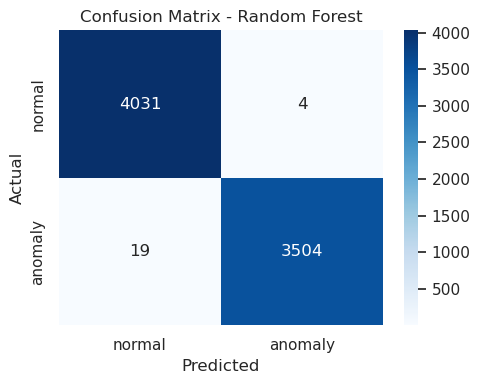

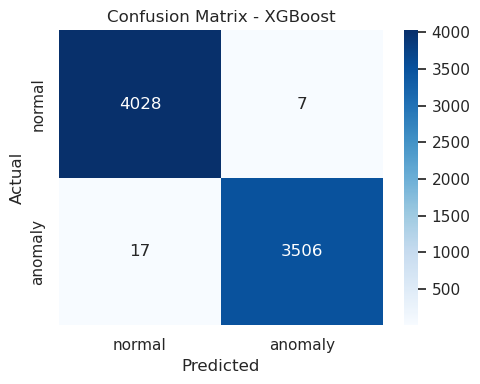

In [10]:
def plot_confusion_matrix(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["normal", "anomaly"],
        yticklabels=["normal", "anomaly"],
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix("Random Forest", rf_pipeline, X_test, y_test)
plot_confusion_matrix("XGBoost", xgb_pipeline, X_test, y_test)

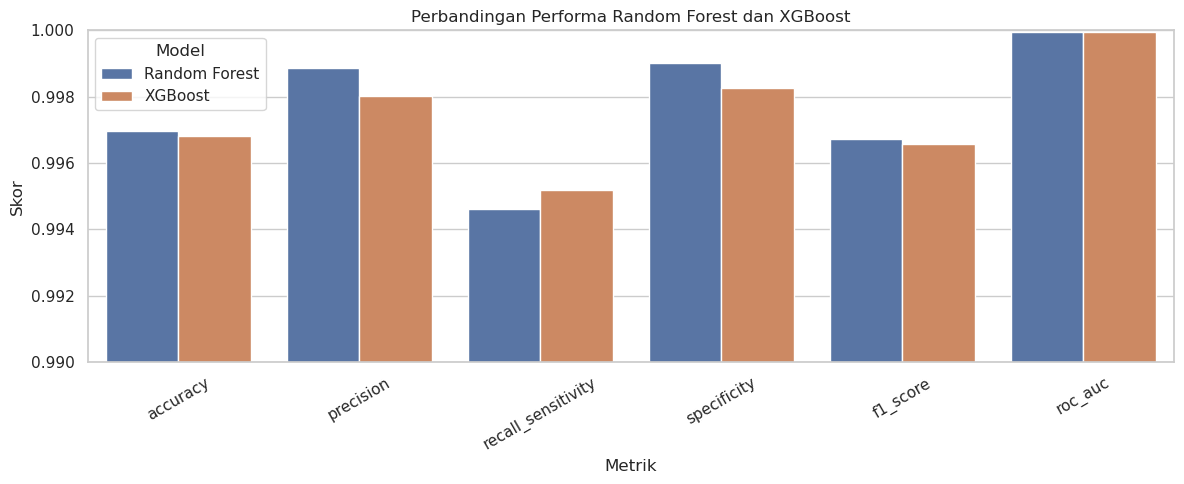

In [11]:
metrics_to_plot = [
    "accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
]

results_melted = results_df.melt(
    id_vars="model",
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(12, 5))
sns.barplot(data=results_melted, x="metric", y="score", hue="model")
plt.ylim(0.99, 1.0)
plt.title("Perbandingan Performa Random Forest dan XGBoost")
plt.xlabel("Metrik")
plt.ylabel("Skor")
plt.xticks(rotation=30)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

## 8. Feature Importance

Feature importance digunakan untuk melihat fitur yang paling banyak berkontribusi terhadap keputusan model. Bagian ini membantu interpretasi model, bukan untuk membuktikan hubungan sebab-akibat.

,feature,importance
82,dst_bytes,0.110869
81,src_bytes,0.103792
106,diff_srv_rate,0.067574
105,same_srv_rate,0.054855
99,count,0.048667
78,flag_SF,0.046055
109,dst_host_srv_count,0.043602
88,logged_in,0.042330
102,srv_serror_rate,0.042261
111,dst_host_diff_srv_rate,0.036241


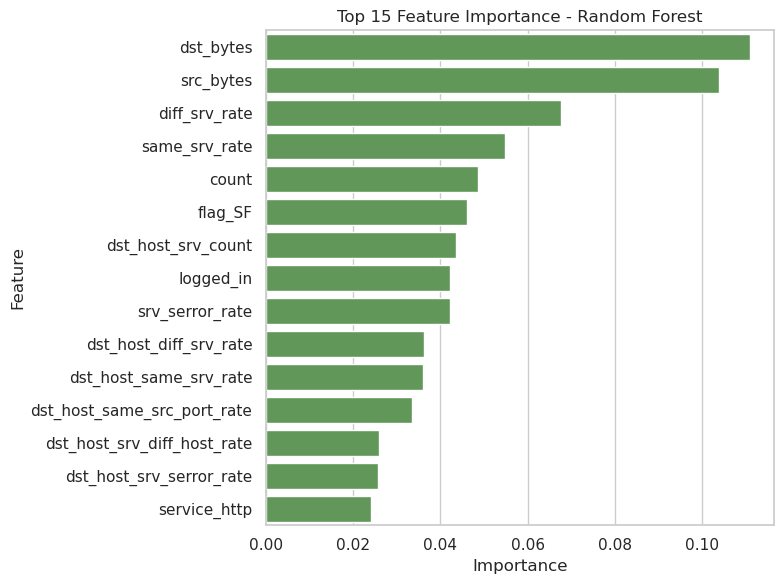

In [12]:
preprocessor = rf_pipeline.named_steps["preprocess"]
rf_model = rf_pipeline.named_steps["model"]

cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
feature_names = np.concatenate([cat_feature_names, numeric_features])

rf_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(rf_importances.head(15))

plt.figure(figsize=(8, 6))
sns.barplot(data=rf_importances.head(15), x="importance", y="feature", color="#59A14F")
plt.title("Top 15 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 9. Kesimpulan

Berdasarkan hasil evaluasi, model Random Forest dan XGBoost sama-sama menunjukkan performa yang sangat baik dalam klasifikasi koneksi jaringan normal dan anomaly. Random Forest memperoleh accuracy, precision, specificity, dan F1-score yang sedikit lebih tinggi. XGBoost memperoleh recall/sensitivity dan ROC-AUC yang sedikit lebih tinggi.

Dalam konteks network intrusion detection, recall/sensitivity penting karena menunjukkan kemampuan model mendeteksi koneksi anomaly yang sebenarnya. Namun, karena selisih performa kedua model sangat kecil dan Random Forest unggul pada lebih banyak metrik utama, Random Forest dapat dipilih sebagai model terbaik secara keseluruhan pada eksperimen ini. XGBoost tetap layak dipertimbangkan apabila prioritas utama sistem adalah meminimalkan anomaly yang tidak terdeteksi.

Secara metodologis, project ini menunjukkan bahwa tahapan Business Understanding, Data Understanding, Data Preparation, Modeling, dan Model Evaluation dapat digunakan secara runut untuk membangun solusi klasifikasi pada kasus network intrusion detection.

## 10. Catatan Lanjutan

Eksperimen berikutnya dapat dilakukan dengan parameter tuning yang lebih lengkap menggunakan Grid Search atau Randomized Search. Selain itu, evaluasi juga dapat diperluas menggunakan validasi silang atau dataset uji berlabel jika tersedia.